Este notebook tiene como objetivo generar las imágenes a utilizar en el artículo de emb2dis.

In [80]:
import sys
import requests
import numpy as np
import pandas as pd
import torch as tr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

sys.path.append("..")
from src.model import BaseModel
from src.utils import ConfigLoader, predict_sliding_window

from Bio.PDB import PDBParser
from matplotlib import gridspec

# Funciones

In [81]:
def get_plddt_from_alphafold(uniprot_id):
    """
    Obtiene los valores de pLDDT para cada residuo a partir de la predicción 
    de AlphaFold, a partir de un ID de UniProt. 
    OJO! Considerar que es el ID de UniProt, no el de DisProt (que es diferente)
    """
    # 1. Consultamos la API para obtener la URL del archivo
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    response = requests.get(api_url)
    data = response.json()[0]
    
    # 2. Descargamos el archivo PDB
    pdb_url = data['pdbUrl']
    pdb_response = requests.get(pdb_url)
    pdb_content = pdb_response.text
    
    # 3. Extraemos pLDDT (columna B-factor en líneas ATOM)
    plddt_values = []
    for line in pdb_content.split('\n'):
        if line.startswith('ATOM') and line[12:16].strip() == 'CA':  # solo Cα
            plddt = float(line[60:66].strip())  # columna B-factor
            residue = int(line[22:26].strip())
            plddt_values.append((residue, plddt))
    
    return plddt_values

# Uso
plddt = get_plddt_from_alphafold("P03934")
for residue, score in plddt[:10]:
    print(f"Residuo {residue:3d}: pLDDT = {score:.2f}")

Residuo   1: pLDDT = 64.88
Residuo   2: pLDDT = 80.06
Residuo   3: pLDDT = 87.38
Residuo   4: pLDDT = 90.00
Residuo   5: pLDDT = 90.25
Residuo   6: pLDDT = 91.31
Residuo   7: pLDDT = 92.56
Residuo   8: pLDDT = 90.94
Residuo   9: pLDDT = 91.12
Residuo  10: pLDDT = 91.75


In [82]:
colors = [
    "#FD3C35",  # 0   → very low
    "#FC6D2F",  # 0   → very low
    "#FF7D45",  # 0   → very low
    "#FFD900",  # 50  → low
    "#7BAFFF",  # 70  → high
    "#0053D6"   # 90+ → very high
]

# Crear un colormap continuo basado en esos puntos
af_cmap = LinearSegmentedColormap.from_list("af_plddt", colors)

In [83]:
from matplotlib.ticker import MultipleLocator


def get_domain_graphs_with_plddt(
        protein,
        results_path, # Path to model results directory (containing config.yaml and weights.pk)
        dataset, # Name of dataset CSV file (without extension)
        uniprot_id=None, # Optional UniProt ID (if different from protein name)
        title=None,
        save_pdf=False,
        output_dir="./disorder_plddt_plots",
        threshold=0.5,
        figsize=(8.25, 3.6),
        region_tracks=None
        ):
    """
    Función que genera gráficos de predicción de desorden junto con una barra
    de colores que representa los valores de pLDDT obtenidos de los archivos de
    AlphaFold para una única proteína.
    """
    # Paths y configuraciones --------------------------------------------------
    results_path = Path(results_path)
    output_dir = Path(output_dir)

    config_loader = ConfigLoader(model_path=results_path / 'config.yaml',
                                 env_path=Path("../config/env.yaml"))
    config = config_loader.load()
    softmax = config['soft_max']
    threshold = threshold

    if region_tracks is None:
        region_tracks = []

    def _parse_region(region):
        start, end, box_color, label = None, None, '#808080', None

        if isinstance(region, dict):
            start = region.get('start')
            end = region.get('end')
            box_color = region.get('color', '#808080')
            label = region.get('label')
        elif isinstance(region, (list, tuple)):
            if len(region) >= 2:
                start, end = region[0], region[1]
            if len(region) >= 3:
                box_color = region[2]
            if len(region) >= 4:
                label = region[3]

        if start is None or end is None:
            return None

        start = float(start)
        end = float(end)
        if end < start:
            start, end = end, start

        return start, end, box_color, label

    # Modelo ------------------------------------------------------------------
    device = 'cuda' if tr.cuda.is_available() else 'cpu'
    model = BaseModel(
        len(config['categories']),
        emb_size=config['emb_size'][config['pLM']],
        lr=config['lr'],
        p_dropout=config['p_dropout'],
        device=device,
        filters=config['filters'],
        kernel_size=config['kernel_size'],
        num_layers=config['n_resnet'])

    # Load weights with appropriate map_location if GPU not available
    state = tr.load(results_path / 'weights.pk', map_location=tr.device(device))
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    # Load the data
    df = pd.read_csv(f"../{config['data_path']}{dataset}.csv")

    # Category colors
    category_colors = {
        "structured": "#0053D6",
        "disordered": "#FC6D2F"
    }

    PID = protein
    if uniprot_id is None:
        uniprot_id = PID

    # ===== Load and predict disorder =====
    emb = np.load(f"../{config['emb_path']}{config['pLM']}/{PID}.npy")
    emb = tr.tensor(emb, dtype=tr.float32)

    centers, pred = predict_sliding_window(model, emb, config['win_len'],
                                           step=1, use_softmax=softmax)

    # Get domains for this protein
    protein_domains = df[df.acc == PID].sort_values(by="start")

    # Load pLDDT via AlphaFold API (no PDB local)
    plddt_values = None
    try:
        fetched = get_plddt_from_alphafold(uniprot_id)
        if fetched and len(fetched) > 0:
            filtered = [(int(r), float(s)) for (r, s) in fetched if r is not None]
            if len(filtered) > 0:
                residues, _ = zip(*filtered)
                max_res = int(max(residues))
                arr = np.full(max_res, np.nan)
                for r, s in filtered:
                    if 1 <= int(r) <= max_res:
                        arr[int(r) - 1] = float(s)
                plddt_values = arr
            else:
                plddt_values = None
        else:
            plddt_values = None
    except Exception as e:
        print(f"Warning: Could not fetch pLDDT from AlphaFold API for {PID}: {e}")
        plddt_values = None

    # FIGURE ------------------------------------------------------------------
    n_region_tracks = len(region_tracks)
    n_rows = 3 + n_region_tracks
    height_ratios = [3, 0.18, 0.35] + [0.3] * n_region_tracks
    hspace = 0.5 if n_region_tracks <= 2 else 0.06

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        n_rows, 1,
        height_ratios=height_ratios,
        hspace=hspace
    )

    # ----- Panel 1: Disorder score -------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])

    color = category_colors.get('disordered', "red")
    ax1.plot(centers, pred[:, 1], "-", color=color, linewidth=1.5, label='Disorder')
    
    # Add domain regions
    if len(protein_domains.shape) == 1:
        domains_list = [protein_domains]
    else:
        domains_list = [protein_domains.iloc[k] for k in range(len(protein_domains))]

    for domain in domains_list:
        color = category_colors.get(domain.label, "gray")
        ax1.axvspan(domain.start, domain.end, ymin=0, ymax=1, alpha=0.2, color=color)

    ax1.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
    ax1.set_xlim([centers.min(), centers.max()])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_ylabel("Disorder score")
    ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax1.grid(alpha=0.3)

    if title:
        ax1.set_title(title)
    else:
        ax1.set_title(f"Protein {PID}")

    # ----- Empty gap row ------------------------------------------------------
    ax_gap = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax_gap.axis('off')

    # ----- Panel 2: pLDDT color bar -------------------------------------------
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax1)

    if plddt_values is not None and len(plddt_values) > 0:
        plddt_norm = plddt_values / 100.0
        plddt_row = plddt_norm[np.newaxis, :]
        ax2.imshow(
            plddt_row,
            aspect="auto",
            origin="lower",
            extent=[1, len(plddt_values), 0, 1],
            cmap=af_cmap,  # Red-Yellow-Green (low to high confidence)
            vmin=0,  # Force minimum value to 0
            vmax=1   # Force maximum value to 1
        )
        ax2.set_yticks([])
        ax2.set_ylabel("pLDDT", rotation=0, labelpad=20, va='center')

        ax2.set_xlim([centers.min(), centers.max()])
        
    else:
        ax2.text(0.5, 0.5, f"No pLDDT data available",
                ha='center', va='center', fontsize=10, color='gray',
                transform=ax2.transAxes)
        ax2.set_xlim([centers.min(), centers.max()])
        ax2.set_xlabel("Amino acids", fontsize=11)
        ax2.set_yticks([])

    # ----- Dynamic region tracks ----------------------------------------------
    region_axes = []
    for i, track in enumerate(region_tracks, start=1):
        row_idx = 2 + i
        ax_track = fig.add_subplot(gs[row_idx, 0], sharex=ax1)
        ax_track.hlines(0.5, centers.min(), centers.max(), color='gray', linewidth=1.5)

        track_label = f"Regions {i}"
        regions = track
        if isinstance(track, dict):
            track_label = track.get('label', track_label)
            regions = track.get('regions', [])

        for region in regions:
            parsed = _parse_region(region)
            if parsed is None:
                continue
            start, end, box_color, label = parsed
            ax_track.axvspan(start, end, ymin=0.15, ymax=0.85, alpha=1, color=box_color, zorder=2)

            if label:
                x_center = (start + end) / 2.0
                ax_track.text(x_center, 0.5, str(label), ha='center', va='center', fontsize=8, color='white')

        ax_track.set_ylim([0, 1])
        ax_track.set_yticks([])
        ax_track.set_ylabel(track_label, rotation=0, labelpad=20, va='center')
        ax_track.set_xlim([centers.min(), centers.max()])
        ax_track.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        region_axes.append(ax_track)

    # X labels and ticks
    if len(region_axes) > 0:
        ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        region_axes[-1].set_xlabel("Amino acids")
        region_axes[-1].tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    else:
        ax2.set_xlabel("Amino acids")
        ax2.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

    for axis in [ax1, ax2] + region_axes:
        axis.xaxis.set_major_locator(MultipleLocator(25))

    # Save as PDF if requested
    if save_pdf:
        pdf_filename = output_dir / f"{PID}_disorder_plddt.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Saved: {pdf_filename.name}")

    plt.show()

    print(f"Plotted: {PID}")
    print()

In [84]:
# Celda de prueba para get_plddt_from_alphafold - P27001
# Ejecuta esto en tu entorno; hace llamadas HTTP a la API de AlphaFold.
try:
    plddt = get_plddt_from_alphafold("P27001")
    print(f"Retrieved {len(plddt)} pLDDT entries for P27001")
    if len(plddt) == 0:
        print("No pLDDT values returned. Revisa conexión o disponibilidad en AlphaFold API.")
    else:
        print("Primeros 20 valores (residuo, pLDDT):")
        for i, (residue, score) in enumerate(plddt[:20], start=1):
            print(f"{i:2d}. Residuo {residue}: pLDDT = {score}")
except Exception as e:
    print("Error durante get_plddt_from_alphafold:", e)

Retrieved 350 pLDDT entries for P27001
Primeros 20 valores (residuo, pLDDT):
 1. Residuo 1: pLDDT = 76.81
 2. Residuo 2: pLDDT = 88.88
 3. Residuo 3: pLDDT = 90.5
 4. Residuo 4: pLDDT = 91.38
 5. Residuo 5: pLDDT = 92.06
 6. Residuo 6: pLDDT = 94.0
 7. Residuo 7: pLDDT = 93.75
 8. Residuo 8: pLDDT = 94.44
 9. Residuo 9: pLDDT = 95.31
10. Residuo 10: pLDDT = 93.69
11. Residuo 11: pLDDT = 94.75
12. Residuo 12: pLDDT = 94.94
13. Residuo 13: pLDDT = 92.69
14. Residuo 14: pLDDT = 92.38
15. Residuo 15: pLDDT = 93.31
16. Residuo 16: pLDDT = 94.19
17. Residuo 17: pLDDT = 94.31
18. Residuo 18: pLDDT = 95.06
19. Residuo 19: pLDDT = 94.25
20. Residuo 20: pLDDT = 94.62


# Probamos funcionamiento

In [85]:
id = "P10912"

c = {
    "missing": "#e377c2ff",
    "structured": "#0053D6",
}

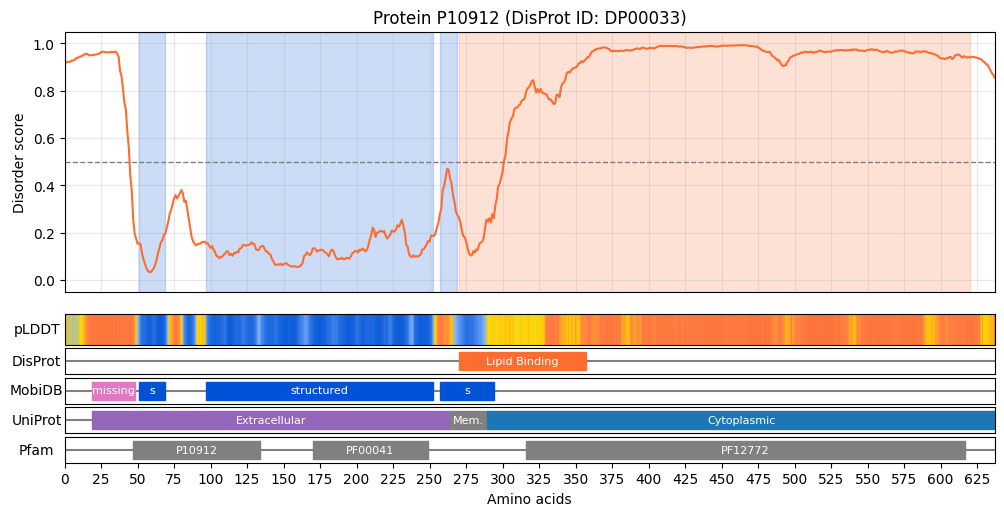

Plotted: P10912



In [86]:
# Ejecutar get_domain_graphs_with_plddt para una proteína
results_path = Path("../model/ESM2/model0/")
# results_path = Path("/home/sduarte/emb2dis/emb2dis_sofiaaduarte/model/esmc_600m/model0/")

# Múltiples pistas/paneles de regiones
custom_region_tracks = [
    {
        "label": "DisProt",
        "regions": [
            (270, 357, "#FC6D2F", "Lipid Binding"),
        ]
    },
    {
        "label": "MobiDB",
        "regions": [
            (19, 48, c['missing'], "missing"),
            (51, 69, c['structured'], "s"),
            (97, 252, c['structured'], "structured"),
            (257, 294, c['structured'], "s")
        ]
    },
    {
        "label": "UniProt",
        "regions": [
            (19, 264, "#9467bdff", "Extracellular"),
            (264, 289, "gray", "Mem."),
            (289, 638, "#1e77b4ff", "Cytoplasmic"),
        ]
    },
    {
        "label": "Pfam",
        "regions": [
            (47, 134, "gray", "P10912"),
            (170, 249, "gray", "PF00041"),
            (316, 617, "gray", "PF12772")
        ]
    },
]

dataset = 'train'

protein = {
    'disprot_id': id,
    'uniprot_id': id
}

try:
    get_domain_graphs_with_plddt(protein=protein["disprot_id"],
                                 results_path=results_path,
                                 dataset=dataset,
                                 uniprot_id=protein['uniprot_id'],
                                 title=f"Protein {protein['uniprot_id']} (DisProt ID: DP00033)",
                                 save_pdf=False,
                                 output_dir="./disorder_plddt_test_plots",
                                 threshold=0.5,
                                 figsize=(12, 5.6),
                                 region_tracks=custom_region_tracks
                                 )
except Exception as e:
    print("Error al ejecutar get_domain_graphs_with_plddt:", e)

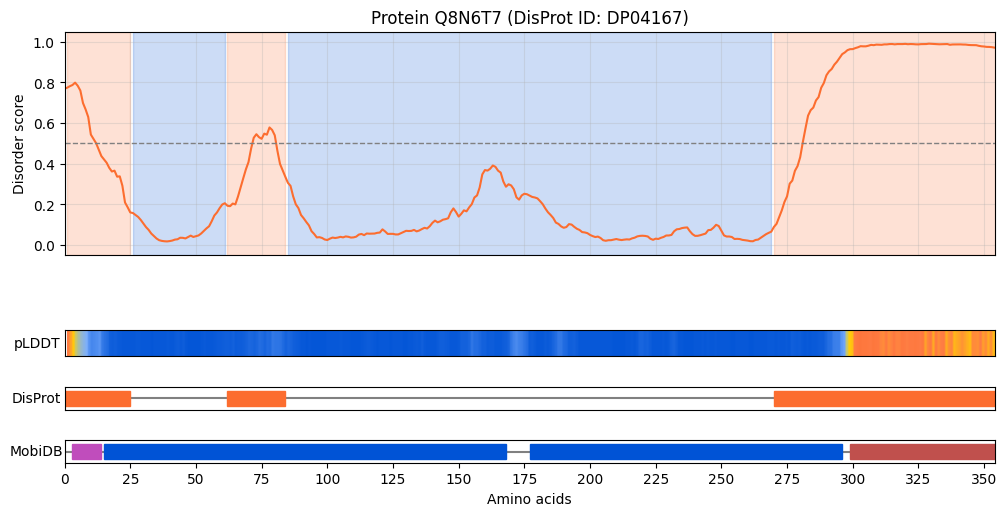

Plotted: DP04167



In [87]:
id = "DP04167"
dataset = 'caid3_3/disorder_pdb'
protein = {
    'disprot_id': id,
    'uniprot_id': "Q8N6T7"
}

c = {
    "missing": "#C0504D",
    "missing_context_dependent": "#C04DBC",
    "structured": "#0053D6",
    "disordered": "#FC6D2F"
}

# Múltiples pistas/paneles de regiones
custom_region_tracks = [
    {
        "label": "DisProt",
        "regions": [
            (0, 25, c['disordered'], ""),
            (62, 84,c['disordered'], ""),
            (270, 355,c['disordered'], ""),
        ]
    },
    {
        "label": "MobiDB",
        "regions": [
            (3, 14, c['missing_context_dependent'], ""),
            (15, 168, c['structured'], ""),
            (177, 296, c['structured'], ""),
            (299, 355, c['missing'], "")
        ]
    },
    # {
    #     "label": "UniProt",
    #     "regions": [
    #         (19, 264, "#C0504D", "Extracellular"),
    #         (264, 289, "gray", "Mem."),
    #         (289, 638, "#88B5D1", "Cytoplasmic"),
    #     ]
    # },
    # {
    #     "label": "Pfam",
    #     "regions": [
    #         (47, 134, "gray", "P10912"),
    #         (170, 249, "gray", "PF00041"),
    #         (316, 617, "gray", "PF12772")
    #     ]
    # },
]


try:
    get_domain_graphs_with_plddt(protein=protein["disprot_id"],
                                 results_path=results_path,
                                 dataset=dataset,
                                 uniprot_id=protein['uniprot_id'],
                                 title=f"Protein {protein['uniprot_id']} (DisProt ID: DP04167)",
                                 save_pdf=False,
                                 output_dir="./disorder_plddt_test_plots",
                                 threshold=0.5,
                                 figsize=(12, 5.6),
                                 region_tracks=custom_region_tracks
                                 )
except Exception as e:
    print("Error al ejecutar get_domain_graphs_with_plddt:", e)



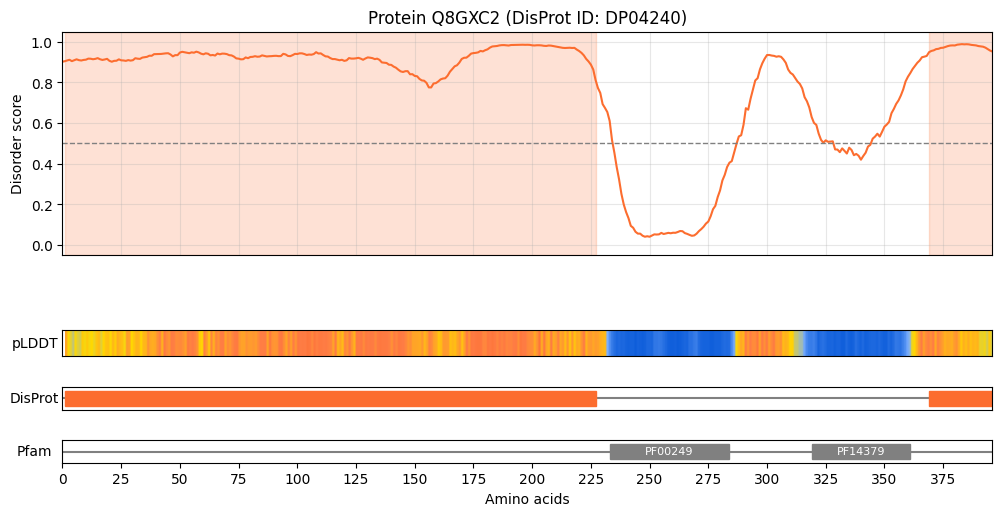

Plotted: DP04240



In [88]:
id = "DP04240"
dataset = 'caid3_3/disorder_pdb'
protein = {
    'disprot_id': id,
    'uniprot_id': "Q8GXC2"
}

c = {
    "missing": "#C0504D",
    "missing_context_dependent": "#C04DBC",
    "structured": "#0053D6",
    "disordered": "#FC6D2F"
}

# Múltiples pistas/paneles de regiones
custom_region_tracks = [
    {
        "label": "DisProt",
        "regions": [
            (1, 227, c['disordered'], ""),
            (369, 397,c['disordered'], ""),
        ]
    },
    {
        "label": "Pfam",
        "regions": [
            (233, 284, "gray", "PF00249"),
            (319, 361, "gray", "PF14379")
        ]
    },
]


try:
    get_domain_graphs_with_plddt(protein=protein["disprot_id"],
                                 results_path=results_path,
                                 dataset=dataset,
                                 uniprot_id=protein['uniprot_id'],
                                 title=f"Protein {protein['uniprot_id']} (DisProt ID: DP04240)",
                                 save_pdf=False,
                                 output_dir="./disorder_plddt_test_plots",
                                 threshold=0.5,
                                 figsize=(12, 5.6),
                                 region_tracks=custom_region_tracks
                                 )
except Exception as e:
    print("Error al ejecutar get_domain_graphs_with_plddt:", e)

